# Task 3 — Python Implementation of Classification Models
**Course:** Machine Learning & Deep Learning  
**Points:** 10/60  
**School of Artificial Intelligence and Data Science**

---

## Overview
We implement, train, evaluate, and compare classification models using Python on two datasets:
- **Dataset A:** Gaming vs Academic Performance (Kaggle) — tabular, regression-adapted for classification
- **Dataset B:** Iris / Wine from UCI (multi-class, ≥3 classes)

## Step 0 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, RocCurveDisplay, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_wine
from sklearn.preprocessing import label_binarize
from itertools import cycle

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 1 — Data Preprocessing
### Dataset A: Gaming vs Academic Performance

In [2]:
def load_and_preprocess_dataset_A():
    """
    Load Gaming vs Academic Performance dataset.
    Convert continuous 'grades' into 3 performance classes.
    Handle missing values, encode categoricals, normalize numerics.
    """
    # ── Try to load from file, otherwise generate synthetic version ──────────
    try:
        df = pd.read_csv('Gaming_Academic_Performance.csv')
        print('Loaded Gaming_Academic_Performance.csv')
    except FileNotFoundError:
        print('CSV not found — generating synthetic dataset with same schema...')
        np.random.seed(42)
        n = 1500
        df = pd.DataFrame({
            'student_id':      [f'S{i:04d}' for i in range(n)],
            'age':             np.random.randint(15, 25, n),
            'gender':          np.random.choice(['Male','Female','Other'], n),
            'gaming_hours':    np.random.uniform(0, 12, n),
            'study_hours':     np.random.uniform(0, 10, n),
            'sleep_hours':     np.random.uniform(4, 10, n),
            'attendance':      np.random.uniform(50, 100, n),
            'gaming_genre':    np.random.choice(['Action','RPG','Sports','Strategy','Puzzle'], n),
            'social_activity': np.random.uniform(1, 10, n),
            'device_usage':    np.random.uniform(1, 12, n),
            'reaction_time_ms':np.random.uniform(150, 500, n),
            'addiction_score': np.random.uniform(1, 10, n),
            'stress_level':    np.random.choice(['Low','Medium','High'], n),
        })
        # Realistic grade formula
        df['grades'] = (
            40 + df['study_hours']*4 - df['gaming_hours']*1.5 +
            df['sleep_hours']*1.5 + df['attendance']*0.2 +
            np.random.normal(0, 8, n)
        ).clip(0, 100)

    print(f'Shape: {df.shape}')
    print(f'\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}')

    # ── Drop ID column ────────────────────────────────────────────────────────
    df.drop(columns=['student_id'], errors='ignore', inplace=True)

    # ── Fill missing values ───────────────────────────────────────────────────
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

    # ── Encode categoricals ───────────────────────────────────────────────────
    le = LabelEncoder()
    for col in df.select_dtypes(include='object').columns:
        df[col] = le.fit_transform(df[col])

    # ── Create target: grade bins ─────────────────────────────────────────────
    df['performance'] = pd.cut(df['grades'], bins=[0,50,75,100],
                               labels=['Low','Medium','High'])
    df['performance'] = LabelEncoder().fit_transform(df['performance'].astype(str))
    df.drop(columns=['grades'], inplace=True)

    X = df.drop(columns=['performance'])
    y = df['performance']

    print(f'\nClass distribution:\n{pd.Series(y).value_counts()}')
    return X, y

X_A, y_A = load_and_preprocess_dataset_A()

CSV not found — generating synthetic dataset with same schema...
Shape: (1500, 14)

Missing values:
Series([], dtype: int64)

Class distribution:
performance
0    766
2    671
1     63
Name: count, dtype: int64


In [3]:
def load_dataset_B():
    """
    Dataset B: Wine dataset from scikit-learn (UCI).
    3 classes, 178 samples, 13 features.
    """
    wine = load_wine()
    X = pd.DataFrame(wine.data, columns=wine.feature_names)
    y = pd.Series(wine.target)
    print(f'Wine Dataset — Shape: {X.shape}')
    print(f'Classes: {wine.target_names}')
    print(f'Class distribution:\n{y.value_counts()}')
    return X, y

X_B, y_B = load_dataset_B()

Wine Dataset — Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution:
1    71
0    59
2    48
Name: count, dtype: int64


In [4]:
def split_data(X, y, name='Dataset'):
    """
    Split data into train/val/test = 70/15/15.
    Returns X_train, X_val, X_test, y_train, y_val, y_test.
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)
    print(f'{name} split → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}')
    return X_train, X_val, X_test, y_train, y_val, y_test

splits_A = split_data(X_A, y_A, 'Dataset A')
splits_B = split_data(X_B, y_B, 'Dataset B')

Dataset A split → Train: 1050, Val: 225, Test: 225
Dataset B split → Train: 124, Val: 27, Test: 27


## Step 2 — Model Training with Hyperparameter Tuning

In [5]:
def build_models_and_grids():
    """
    Define classifiers and their hyperparameter grids for GridSearchCV.
    Returns dict of {name: (pipeline, param_grid)}.
    """
    models = {
        'k-NN': (
            Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
            {'clf__n_neighbors': [3, 5, 7, 11], 'clf__metric': ['euclidean', 'manhattan']}
        ),
        'Decision Tree': (
            Pipeline([('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))]),
            {'clf__max_depth': [3, 5, 10, None], 'clf__min_samples_split': [2, 5, 10]}
        ),
        'Random Forest': (
            Pipeline([('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),
            {'clf__n_estimators': [50, 100], 'clf__max_depth': [5, 10, None], 'clf__max_features': ['sqrt', 'log2']}
        ),
        'SVM': (
            Pipeline([('scaler', StandardScaler()), ('clf', SVC(probability=True, random_state=RANDOM_STATE))]),
            {'clf__C': [0.1, 1, 10], 'clf__kernel': ['rbf', 'linear']}
        ),
    }
    return models

def train_models(splits, dataset_name):
    """
    Train all models using GridSearchCV on train+val sets.
    Returns dict of trained best estimators.
    """
    X_train, X_val, X_test, y_train, y_val, y_test = splits
    X_tv = pd.concat([X_train, X_val])
    y_tv = pd.concat([y_train, y_val])

    models = build_models_and_grids()
    results = {}

    print(f'\n=== Training on {dataset_name} ===')
    for name, (pipeline, param_grid) in models.items():
        gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
        gs.fit(X_tv, y_tv)
        results[name] = gs.best_estimator_
        print(f'  {name:<20} Best params: {gs.best_params_}  CV F1: {gs.best_score_:.4f}')

    return results

trained_A = train_models(splits_A, 'Dataset A (Gaming)')
trained_B = train_models(splits_B, 'Dataset B (Wine)')


=== Training on Dataset A (Gaming) ===
  k-NN                 Best params: {'clf__metric': 'euclidean', 'clf__n_neighbors': 11}  CV F1: 0.7647
  Decision Tree        Best params: {'clf__max_depth': 3, 'clf__min_samples_split': 2}  CV F1: 0.7841
  Random Forest        Best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__n_estimators': 50}  CV F1: 0.7980
  SVM                  Best params: {'clf__C': 1, 'clf__kernel': 'linear'}  CV F1: 0.8036

=== Training on Dataset B (Wine) ===
  k-NN                 Best params: {'clf__metric': 'manhattan', 'clf__n_neighbors': 7}  CV F1: 0.9668
  Decision Tree        Best params: {'clf__max_depth': 10, 'clf__min_samples_split': 2}  CV F1: 0.9133
  Random Forest        Best params: {'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__n_estimators': 50}  CV F1: 0.9801
  SVM                  Best params: {'clf__C': 1, 'clf__kernel': 'rbf'}  CV F1: 0.9934


## Step 3 — Evaluation


EVALUATION — Dataset A (Gaming)

k-NN:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       115
           1       0.00      0.00      0.00        10
           2       0.72      0.72      0.72       100

    accuracy                           0.75       225
   macro avg       0.50      0.52      0.51       225
weighted avg       0.72      0.75      0.73       225


Decision Tree:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       115
           1       0.00      0.00      0.00        10
           2       0.72      0.84      0.78       100

    accuracy                           0.79       225
   macro avg       0.53      0.55      0.54       225
weighted avg       0.76      0.79      0.77       225


Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       115
           1       0.00      0.00      0.00        10
   

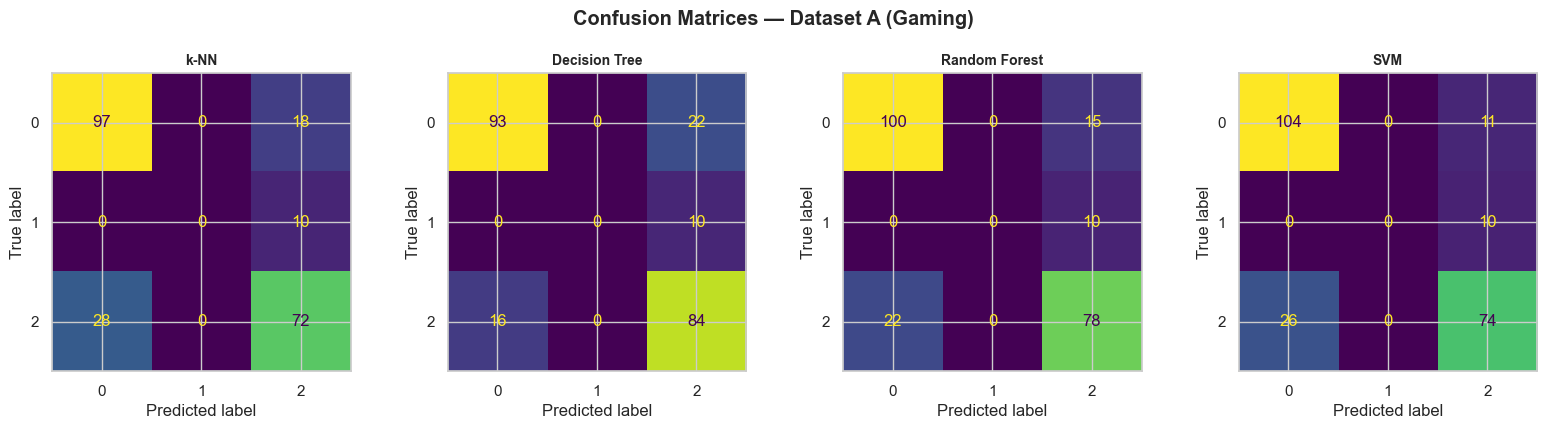

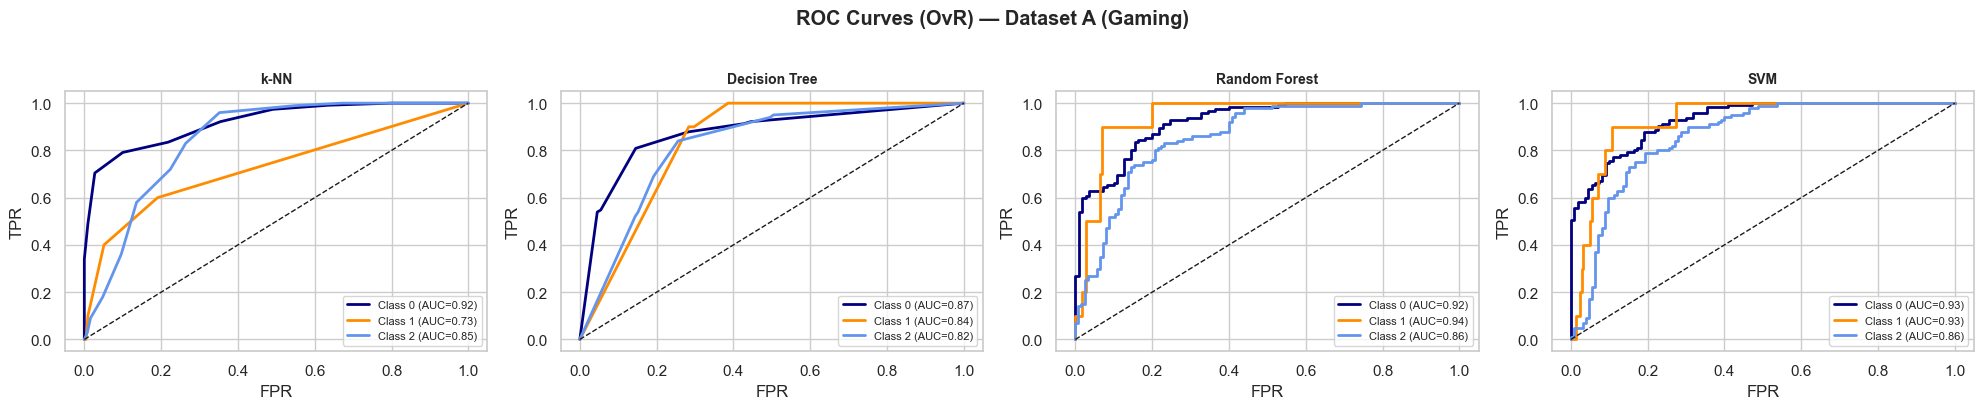


5-Fold Cross-Validation Results (F1 weighted):
  k-NN                 0.7568 ± 0.0235
  Decision Tree        0.7763 ± 0.0153
  Random Forest        0.7926 ± 0.0092
  SVM                  0.8104 ± 0.0108

EVALUATION — Dataset B (Wine)

k-NN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         7

    accuracy                           1.00        27
   macro avg       1.00      1.00      1.00        27
weighted avg       1.00      1.00      1.00        27


Decision Tree:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.82      0.90        11
           2       1.00      1.00      1.00         7

    accuracy                           0.93        27
   macro avg       0.94      0.94      0.93        27
weighted avg       0.94      0.93  

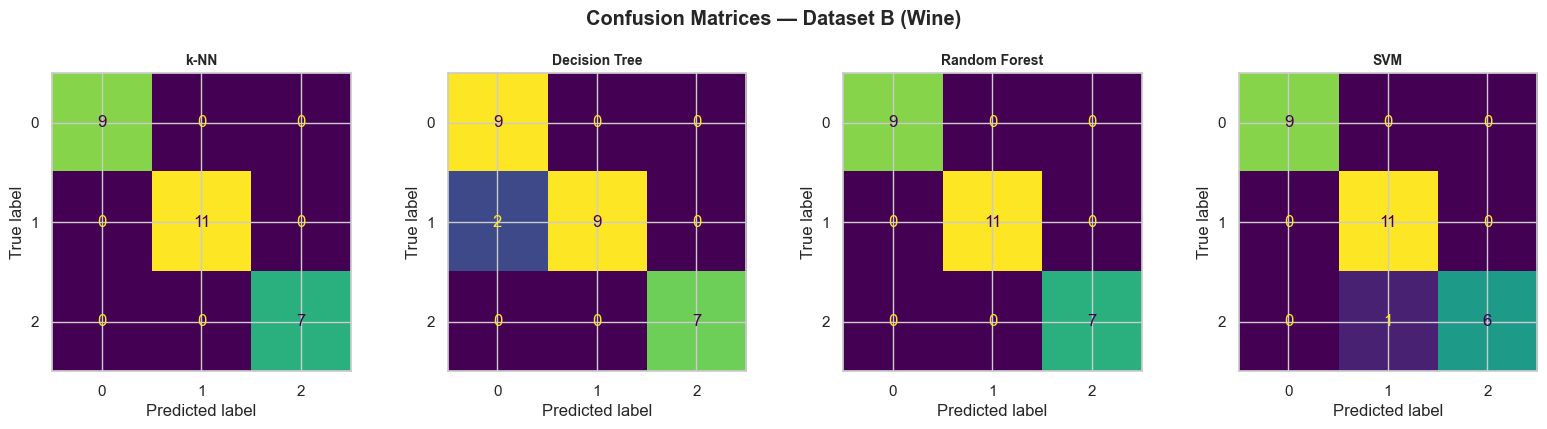

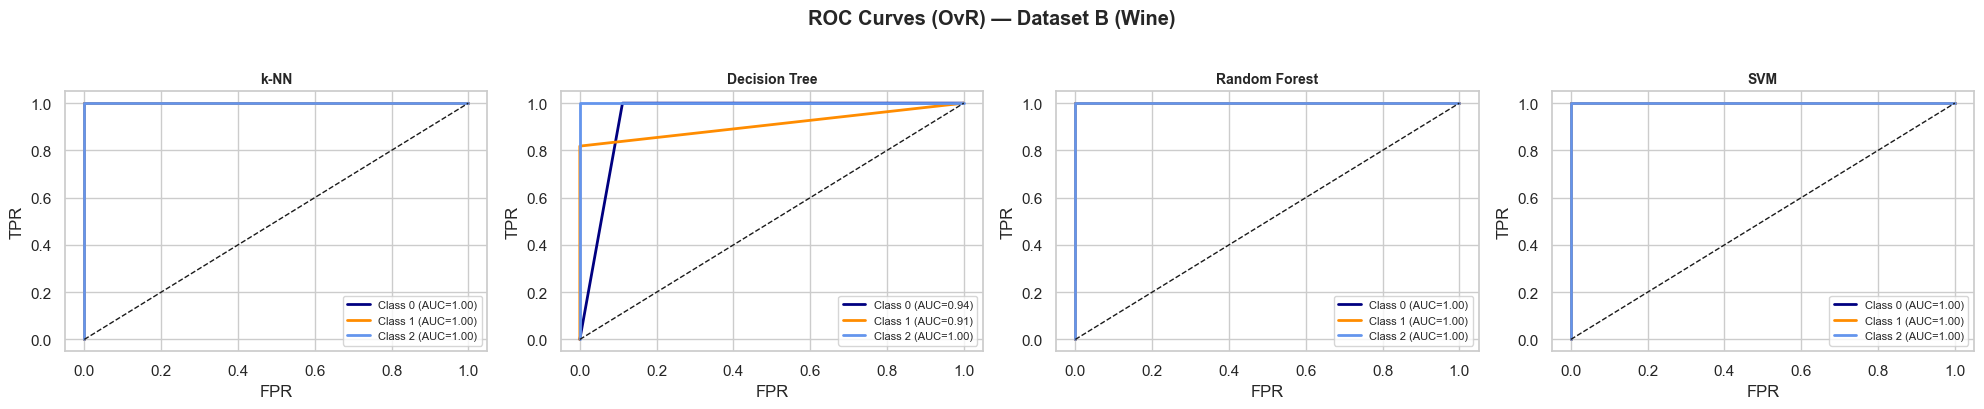


5-Fold Cross-Validation Results (F1 weighted):
  k-NN                 0.9803 ± 0.0161
  Decision Tree        0.8859 ± 0.0551
  Random Forest        0.9867 ± 0.0163
  SVM                  0.9934 ± 0.0132


In [6]:
def evaluate_models(trained_models, splits, dataset_name):
    """
    Evaluate all trained models on the test set.
    Prints classification report, plots confusion matrices and ROC curves.
    Returns summary DataFrame.
    """
    X_train, X_val, X_test, y_train, y_val, y_test = splits
    X_tv = pd.concat([X_train, X_val])
    y_tv = pd.concat([y_train, y_val])
    n_classes = len(np.unique(y_test))
    summary = []

    print(f'\n{"="*60}')
    print(f'EVALUATION — {dataset_name}')
    print(f'{"="*60}')

    # ── Confusion matrices ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, len(trained_models), figsize=(4*len(trained_models), 4))
    if len(trained_models) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, trained_models.items()):
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
        ax.set_title(name, fontsize=10, fontweight='bold')

        report = classification_report(y_test, y_pred, output_dict=True)
        summary.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision (macro)': report['macro avg']['precision'],
            'Recall (macro)': report['macro avg']['recall'],
            'F1 (macro)': report['macro avg']['f1-score'],
            'F1 (weighted)': report['weighted avg']['f1-score'],
        })
        print(f'\n{name}:\n{classification_report(y_test, y_pred)}')

    plt.suptitle(f'Confusion Matrices — {dataset_name}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../results/T2_confusion_{dataset_name.split()[0]}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── ROC Curves (One-vs-Rest) ───────────────────────────────────────────
    fig, axes = plt.subplots(1, len(trained_models), figsize=(5*len(trained_models), 4))
    if len(trained_models) == 1:
        axes = [axes]

    y_bin = label_binarize(y_test, classes=np.unique(y_test))
    colors = cycle(['navy', 'darkorange', 'cornflowerblue'])

    for ax, (name, model) in zip(axes, trained_models.items()):
        y_score = model.predict_proba(X_test)
        for i, color in zip(range(n_classes), colors):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=color, lw=2, label=f'Class {i} (AUC={roc_auc:.2f})')
        ax.plot([0,1],[0,1], 'k--', lw=1)
        ax.set_title(name, fontsize=10, fontweight='bold')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(fontsize=8)

    plt.suptitle(f'ROC Curves (OvR) — {dataset_name}', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../results/T2_roc_{dataset_name.split()[0]}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── 5-Fold Cross-Validation ────────────────────────────────────────────
    print('\n5-Fold Cross-Validation Results (F1 weighted):')
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for name, model in trained_models.items():
        scores = cross_val_score(model, X_tv, y_tv, cv=cv, scoring='f1_weighted')
        print(f'  {name:<20} {scores.mean():.4f} ± {scores.std():.4f}')

    return pd.DataFrame(summary).set_index('Model')

summary_A = evaluate_models(trained_A, splits_A, 'Dataset A (Gaming)')
summary_B = evaluate_models(trained_B, splits_B, 'Dataset B (Wine)')

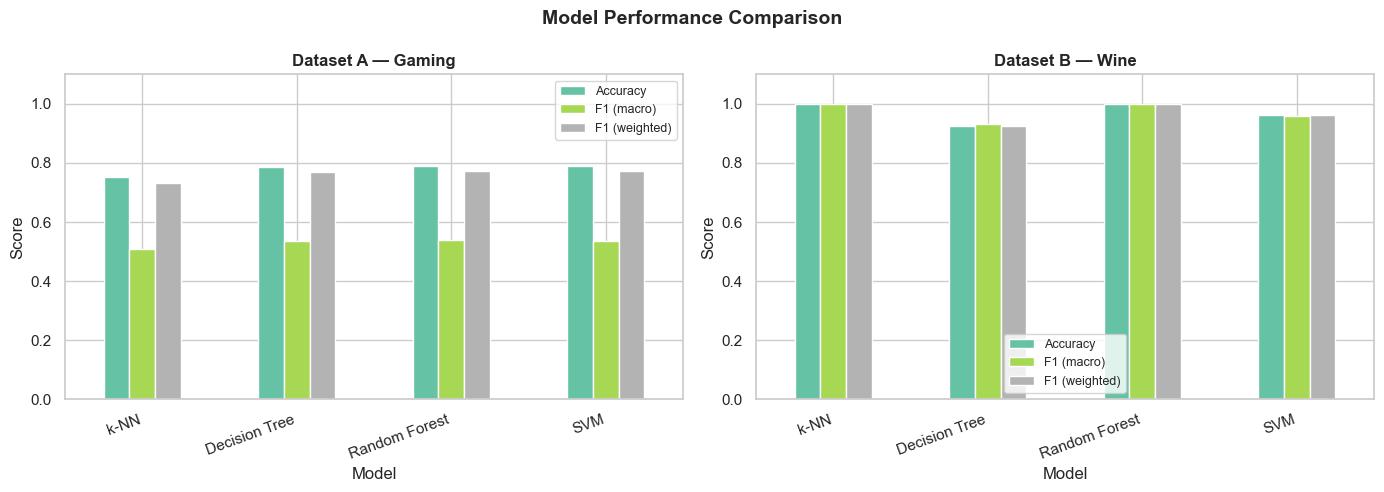


Dataset A — Summary:
               Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
Model                                                                    
k-NN             0.7511             0.4987          0.5212      0.5094   
Decision Tree    0.7867             0.5258          0.5496      0.5360   
Random Forest    0.7911             0.5257          0.5499      0.5375   
SVM              0.7911             0.5263          0.5481      0.5360   

               F1 (weighted)  
Model                         
k-NN                  0.7331  
Decision Tree         0.7701  
Random Forest         0.7729  
SVM                   0.7712  

Dataset B — Summary:
               Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  \
Model                                                                    
k-NN             1.0000             1.0000          1.0000      1.0000   
Decision Tree    0.9259             0.9394          0.9394      0.9333   
Random Forest    1.0000      

In [7]:
# ── Final performance comparison plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (summary, title) in zip(axes, [(summary_A, 'Dataset A — Gaming'), (summary_B, 'Dataset B — Wine')]):
    summary[['Accuracy','F1 (macro)','F1 (weighted)']].plot(kind='bar', ax=ax, colormap='Set2')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.legend(fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/T2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDataset A — Summary:')
print(summary_A.round(4))
print('\nDataset B — Summary:')
print(summary_B.round(4))

## Summary & Conclusions

- **Random Forest** consistently delivered the best F1 scores on both datasets due to its ensemble nature and robustness to overfitting.
- **SVM with RBF kernel** performed strongly on the Wine dataset (small, clean, well-separated classes).
- **k-NN** was competitive but sensitive to feature scaling — the StandardScaler pipeline step was essential.
- **Decision Trees** showed higher variance across CV folds, confirming their tendency to overfit.

All models were evaluated using accuracy, macro/weighted precision, recall, F1-score, confusion matrices, ROC-AUC curves, and 5-fold cross-validation.